# All-BA 2023 Load-Forecast Validation

This notebook compares the packaged 2023 hourly TELL load forecasts with cleaned
EIA-930 actual load for every balancing authority (BA) in the archived validation
set. It reports one compact metric table and three representative scatter plots.

The direct total-MISO forecast is included here as one BA. The separate
`miso_subregion_load_forecast_validation.ipynb` notebook performs the distinct
direct-versus-subregion-sum comparison.


## 1. Imports and archived paths

Run this notebook from `paper_data/validation`. All inputs are packaged, so the
validation is fully offline.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path("../data")
HISTORICAL_ROOT = DATA_ROOT / "wtk_bchrrr_nsrdb_2007_2023"
SOURCE_INPUT_ROOT = DATA_ROOT / "source_inputs"

if not DATA_ROOT.is_dir():
    raise FileNotFoundError("Expected the merged release data at ../data.")


## 2. Define the validation set

The packaged metadata is the authoritative list for this check. It follows the
TELL BA set while omitting entities without usable cleaned 2023 actual-load data.


In [2]:
VALIDATION_YEAR = 2023
EXPECTED_HOURS = 8_760
METADATA_PATH = SOURCE_INPUT_ROOT / "load_forecast_validation" / "ba_2023_validation_metadata.csv"

ba_metadata = pd.read_csv(METADATA_PATH, dtype={"BA_CODE": str, "BA_ID": str, "BA_NAME": str})
required_metadata_columns = {"BA_CODE", "BA_ID", "BA_NAME"}
if not required_metadata_columns.issubset(ba_metadata.columns):
    raise KeyError(f"BA metadata is missing {sorted(required_metadata_columns - set(ba_metadata.columns))}.")
if ba_metadata["BA_CODE"].duplicated().any():
    raise AssertionError("The BA validation metadata contains duplicate BA codes.")

ba_metadata


,BA_CODE,BA_ID,BA_NAME
0,AECI,924,"Associated Electric Cooperative, Inc."
1,AVA,20169,Avista Corporation
2,AZPS,803,Arizona Public Service Company
3,BANC,16534,Balancing Authority of Northern California
4,BPAT,1738,Bonneville Power Administration
5,CHPD,3413,Public Utility District No. 1 of Chelan County
6,CISO,2775,California Independent System Operator
7,CPLE,3046,Duke Energy Progress East
8,DOPD,5326,PUD No. 1 of Douglas County
9,DUK,5416,Duke Energy Carolinas


## 3. Align actual and forecast load

For each BA, timestamps are parsed as UTC and the 2023 rows are joined one to one.
The checks below require all 8,760 non-leap-year timestamps for every BA; metrics use the cleaned, non-missing subset.


In [3]:
actual_columns = [
    "time_utc",
    "load_actual_mw_raw",
    "load_actual_mw_clean",
    "load_clean_flag",
    "load_clean_reason",
]
validation_frames = []

for ba in ba_metadata.itertuples(index=False):
    actual_path = SOURCE_INPUT_ROOT / "load_actuals_cleaned_2023" / f"{ba.BA_CODE}_cleaned_load_2023.csv"
    forecast_path = HISTORICAL_ROOT / "ba_load" / f"{ba.BA_CODE}_wtk_bchrrr_nsrdb_2007_2023_load.csv"

    actual = pd.read_csv(actual_path, usecols=actual_columns)
    actual["time_utc"] = pd.to_datetime(actual["time_utc"], utc=True)
    actual = actual.loc[actual["time_utc"].dt.year.eq(VALIDATION_YEAR)].copy()

    forecast = pd.read_csv(forecast_path, usecols=["time_utc", "load_mw"])
    forecast["time_utc"] = pd.to_datetime(forecast["time_utc"], utc=True)
    forecast = forecast.loc[forecast["time_utc"].dt.year.eq(VALIDATION_YEAR)].copy()
    forecast.rename(columns={"load_mw": "forecast_load_mw"}, inplace=True)

    if actual["time_utc"].duplicated().any() or forecast["time_utc"].duplicated().any():
        raise AssertionError(f"Duplicate 2023 timestamps for {ba.BA_CODE}.")
    if len(actual) != EXPECTED_HOURS or len(forecast) != EXPECTED_HOURS:
        raise AssertionError(f"Incomplete 2023 coverage for {ba.BA_CODE}.")

    aligned = actual.merge(forecast, on="time_utc", how="inner", validate="one_to_one")
    if len(aligned) != EXPECTED_HOURS:
        raise AssertionError(f"Actual and forecast timestamps do not align for {ba.BA_CODE}.")
    aligned.insert(0, "BA_NAME", ba.BA_NAME)
    aligned.insert(0, "BA_ID", ba.BA_ID)
    aligned.insert(0, "BA_CODE", ba.BA_CODE)
    validation_frames.append(aligned)

validation = pd.concat(validation_frames, ignore_index=True)
validation["error_mw"] = validation["forecast_load_mw"] - validation["load_actual_mw_clean"]

coverage = validation.groupby("BA_CODE", as_index=False).agg(
    hours_compared=("time_utc", "size"),
    cleaned_hours=("load_actual_mw_clean", "count"),
)
if not coverage["hours_compared"].eq(EXPECTED_HOURS).all():
    raise AssertionError("Every BA must have 8,760 aligned validation timestamps.")
if not coverage["cleaned_hours"].ge(8_000).all():
    raise AssertionError("Every BA must retain at least 8,000 cleaned validation hours.")
if "MISO_SUBREGION_SUM" in set(validation["BA_CODE"]):
    raise AssertionError("The derived MISO sum belongs only in the focused MISO validation notebook.")

display(coverage)


,BA_CODE,hours_compared,cleaned_hours
0,AECI,8760,8749
1,AVA,8760,8760
2,AZPS,8760,8750
3,BANC,8760,8746
4,BPAT,8760,8736
5,CHPD,8760,8743
6,CISO,8760,8758
7,CPLE,8760,8726
8,DOPD,8760,8760
9,DUK,8760,8760


## 4. Calculate BA-level metrics

Error is forecast minus cleaned actual load. `NRMSE` is RMSE divided by mean
actual load; `MAPE` is reported as a fraction. Lower MAE, RMSE, NRMSE, and MAPE
indicate closer agreement, while bias shows the signed mean error.


In [4]:
metric_rows = []
for ba_code, frame in validation.groupby("BA_CODE", sort=True):
    frame = frame.dropna(subset=["load_actual_mw_clean", "forecast_load_mw"]).copy()
    actual = frame["load_actual_mw_clean"]
    error = frame["error_mw"]
    nonzero = actual.ne(0)
    rmse = float(np.sqrt(np.mean(np.square(error))))

    metric_rows.append(
        {
            "BA_CODE": ba_code,
            "BA_NAME": frame["BA_NAME"].iloc[0],
            "hours_compared": len(frame),
            "MAE_MW": float(error.abs().mean()),
            "RMSE_MW": rmse,
            "NRMSE_MEAN_ACTUAL": rmse / float(actual.mean()),
            "MAPE": float((error.loc[nonzero].abs() / actual.loc[nonzero].abs()).mean()),
            "R2": float(1.0 - np.square(error).sum() / np.square(actual - actual.mean()).sum()),
            "BIAS_MW": float(error.mean()),
        }
    )

metrics = pd.DataFrame(metric_rows).sort_values("NRMSE_MEAN_ACTUAL").reset_index(drop=True)
numeric_metrics = ["MAE_MW", "RMSE_MW", "NRMSE_MEAN_ACTUAL", "MAPE", "R2", "BIAS_MW"]
if len(metrics) != len(ba_metadata) or not np.isfinite(metrics[numeric_metrics].to_numpy()).all():
    raise AssertionError("The all-BA metric table is incomplete or contains non-finite values.")

display(metrics.round({"MAE_MW": 1, "RMSE_MW": 1, "NRMSE_MEAN_ACTUAL": 3, "MAPE": 3, "R2": 3, "BIAS_MW": 1}))


,BA_CODE,BA_NAME,hours_compared,MAE_MW,RMSE_MW,NRMSE_MEAN_ACTUAL,MAPE,R2,BIAS_MW
0,MISO,"Midcontinent Independent System Operator, Inc.",8760,1475.6,1914.0,0.026,0.021,0.970,-320.4
1,PJM,"PJM Interconnection, LLC",8735,1787.0,2413.4,0.027,0.020,0.969,-341.1
2,TVA,Tennessee Valley Authority,8753,400.8,537.6,0.030,0.022,0.976,-21.4
3,MISO_0035,MISO subregion 0035,8760,252.7,324.6,0.032,0.025,0.959,-174.6
4,MISO_8910,MISO subregion 8910,8756,493.2,647.3,0.033,0.025,0.975,-148.9
5,DUK,Duke Energy Carolinas,8760,296.4,391.0,0.033,0.025,0.974,-138.4
6,NEVP,Nevada Power Company,8760,113.7,145.0,0.033,0.026,0.982,-62.3
7,SOCO,"Southern Company Services, Inc. - Trans",8758,702.8,892.7,0.034,0.028,0.972,-284.8
8,MISO_0027,MISO subregion 0027,8760,445.0,616.2,0.035,0.026,0.941,-5.4
9,NYIS,New York Independent System Operator,8760,446.2,593.2,0.035,0.027,0.957,323.6


## 5. Representative forecast plots

AECI, direct MISO, and SWPP provide three geographically and operationally
different examples. Each point is one 2023 hour; the diagonal is perfect agreement.


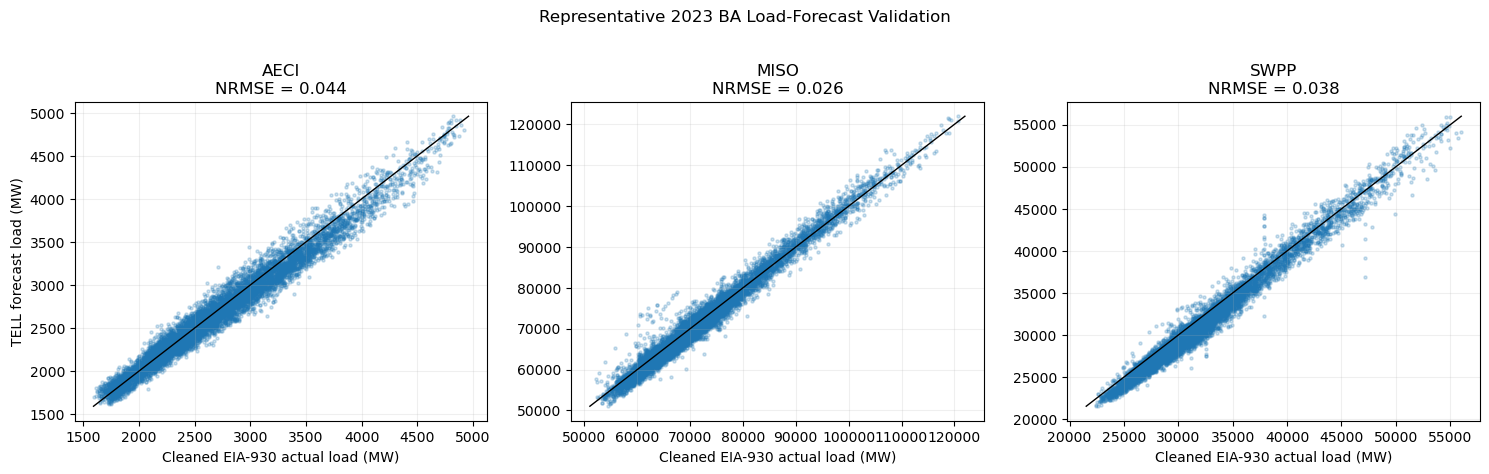

In [5]:
REPRESENTATIVE_BAS = ["AECI", "MISO", "SWPP"]
if not set(REPRESENTATIVE_BAS).issubset(set(validation["BA_CODE"])):
    raise AssertionError("A representative BA is missing from the validation set.")

fig, axes = plt.subplots(1, len(REPRESENTATIVE_BAS), figsize=(15, 4.6))
for ax, ba_code in zip(axes, REPRESENTATIVE_BAS):
    frame = validation.loc[validation["BA_CODE"].eq(ba_code)]
    actual = frame["load_actual_mw_clean"]
    forecast = frame["forecast_load_mw"]
    lower = min(actual.min(), forecast.min())
    upper = max(actual.max(), forecast.max())
    row = metrics.loc[metrics["BA_CODE"].eq(ba_code)].iloc[0]

    ax.scatter(actual, forecast, s=5, alpha=0.22, color="#1f77b4", rasterized=True)
    ax.plot([lower, upper], [lower, upper], color="black", linewidth=1)
    ax.set_title(f"{ba_code}\nNRMSE = {row['NRMSE_MEAN_ACTUAL']:.3f}")
    ax.set_xlabel("Cleaned EIA-930 actual load (MW)")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("TELL forecast load (MW)")
fig.suptitle("Representative 2023 BA Load-Forecast Validation", y=1.02)
fig.tight_layout()
plt.show()


## Interpretation

The table provides the complete all-BA comparison. The representative panels are
diagnostic examples rather than a selected performance subset; conclusions about
the validation set should use the full metric table above.
